# Emotion Classification with DistilBERT

**Course**: 42850 Natural Language Processing Algorithms - Autumn 2026  
**Group**: 10  
**Model**: DistilBERT-base-uncased (Lightweight Pre-trained Transformer)

## Overview
This notebook implements emotion classification using **DistilBERT**, a distilled version of BERT that retains 97% of BERT's performance while being 60% faster and 40% smaller. This makes it ideal for real-time Text-to-Speech (TTS) applications where inference speed matters.

### Key Features:
- **Efficiency**: Fast training and inference suitable for production TTS systems
- **Performance**: Near-BERT accuracy with significantly reduced computational cost
- **Knowledge Distillation**: Demonstrates how large models can be compressed
- **Comparison**: Complements existing experiments (RoBERTa, BiLSTM, Custom Transformer)

## 1. Setup & Dependencies

In [1]:
# =============================================================================
# Setup for SageMaker DistilBERT Experiment (Stable Version)
# =============================================================================

# Install compatible package versions
%pip install -q \
datasets==2.19.1 \
transformers==4.41.2 \
accelerate==0.30.1 \
evaluate==0.4.2 \
pyarrow==15.0.2 \
tokenizers==0.19.1 \
huggingface_hub==0.23.0 \
scikit-learn==1.5.0

print("✅ Packages installed")

Note: you may need to restart the kernel to use updated packages.
✅ Packages installed


In [2]:
# 2. Imports
import warnings
warnings.filterwarnings('ignore')

import random
import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score
)
print("✅ Import successful")

2026-05-09 12:26:09.720679: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 12:26:09.735370: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778329569.754995    9957 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778329569.761556    9957 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778329569.777990    9957 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ Import successful


In [3]:

# 3. Configuration

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 2. Load Dataset

In [4]:
# Load the same dataset same as other experiments
raw = load_dataset('mteb/emotion')

# Convert to pandas DataFrames
train_df = raw['train'].to_pandas()
val_df = raw['validation'].to_pandas()
test_df = raw['test'].to_pandas()

print(f"Columns: {list(train_df.columns)}")
print(f"\nRows — train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
print(f"\nFirst 5 rows (train):")
train_df.head(5)

Columns: ['text', 'label', 'label_text']

Rows — train: 15956 | val: 1988 | test: 1986

First 5 rows (train):


,text,label,label_text
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 3. Exploratory Data Analysis (EDA)

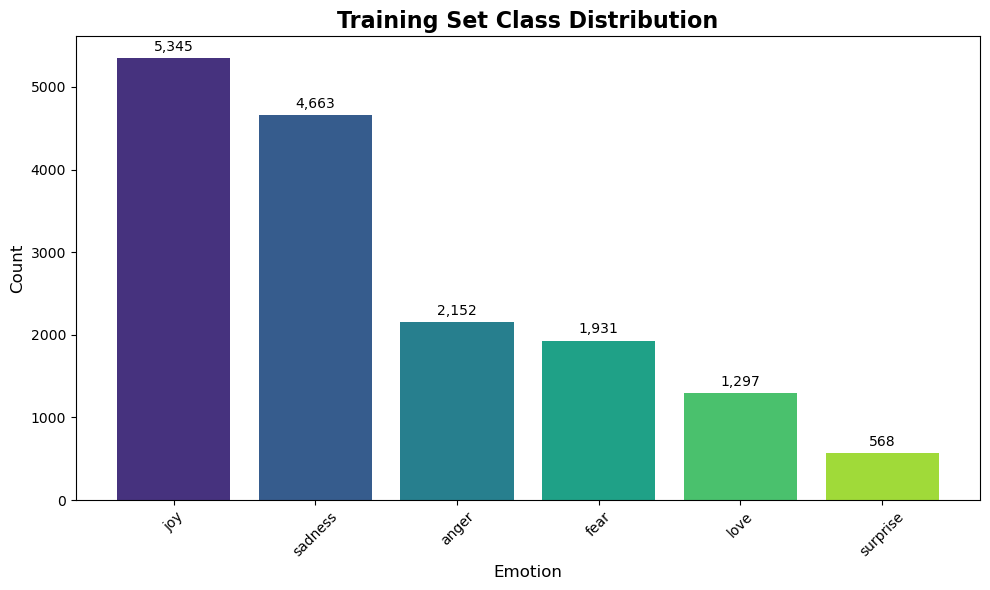

Class Distribution Statistics:
  Most frequent: joy (5,345 samples)
  Least frequent: surprise (568 samples)
  Imbalance ratio: 9.41x


In [5]:
# 1. Class distribution analysis
class_counts = train_df['label_text'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', len(class_counts)))
plt.title('Training Set Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('distilbert_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class Distribution Statistics:")
print(f"  Most frequent: {class_counts.index[0]} ({class_counts.values[0]:,} samples)")
print(f"  Least frequent: {class_counts.index[-1]} ({class_counts.values[-1]:,} samples)")
print(f"  Imbalance ratio: {class_counts.values[0] / class_counts.values[-1]:.2f}x")

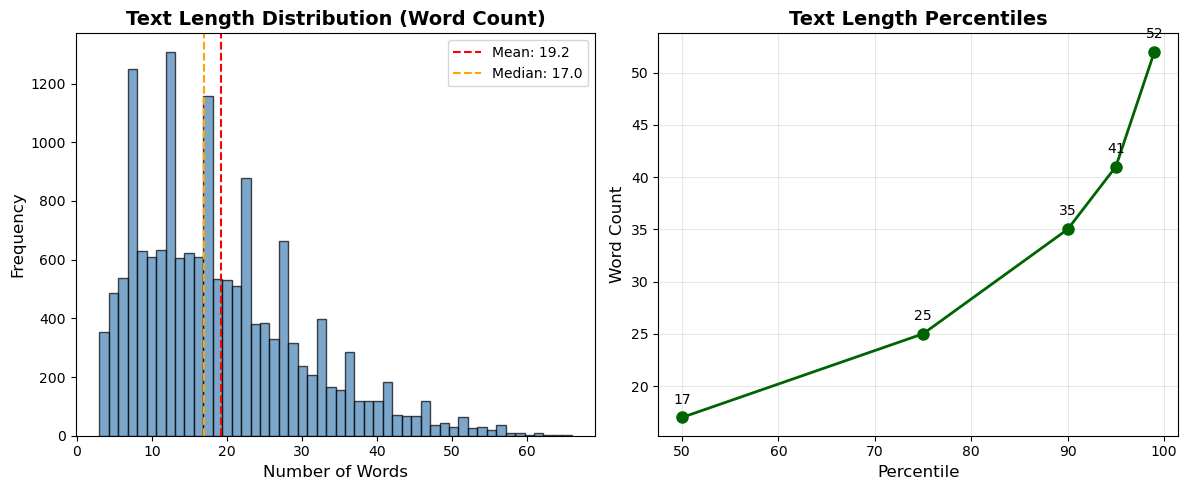

Text Length Statistics:
  Mean: 19.2 words
  Median: 17.0 words
  95th percentile: 41 words
  Max: 66 words


In [6]:
# 2. Text length distribution
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Text Length Distribution (Word Count)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(train_df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['text_length'].mean():.1f}")
plt.axvline(train_df['text_length'].median(), color='orange', linestyle='--', label=f"Median: {train_df['text_length'].median():.1f}")
plt.legend()

plt.subplot(1, 2, 2)
percentiles = [50, 75, 90, 95, 99]
values = [np.percentile(train_df['text_length'], p) for p in percentiles]
plt.plot(percentiles, values, 'o-', color='darkgreen', linewidth=2, markersize=8)
plt.title('Text Length Percentiles', fontsize=14, fontweight='bold')
plt.xlabel('Percentile', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.grid(True, alpha=0.3)

for p, v in zip(percentiles, values):
    plt.annotate(f'{v:.0f}', (p, v), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig('distilbert_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Text Length Statistics:")
print(f"  Mean: {train_df['text_length'].mean():.1f} words")
print(f"  Median: {train_df['text_length'].median():.1f} words")
print(f"  95th percentile: {np.percentile(train_df['text_length'], 95):.0f} words")
print(f"  Max: {train_df['text_length'].max()} words")

## 4. Label Preparation

In [7]:
# Prepare label mappings (consistent with other notebooks)
labels_sorted = sorted(train_df['label'].unique())
assert labels_sorted == list(range(len(labels_sorted))), "Labels should be 0..K-1"

num_classes = len(labels_sorted)
id2label = train_df.drop_duplicates('label').set_index('label')['label_text'].to_dict()
label2id = {v: k for k, v in id2label.items()}

print(f"num_classes: {num_classes}")
print(f"id2label: {id2label}")
print(f"label2id: {label2id}")

num_classes: 6
id2label: {0: 'sadness', 3: 'anger', 2: 'love', 5: 'surprise', 4: 'fear', 1: 'joy'}
label2id: {'sadness': 0, 'anger': 3, 'love': 2, 'surprise': 5, 'fear': 4, 'joy': 1}


## 5. Tokenizer Setup

In [8]:
# 1. Load DistilBERT tokenizer
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 128  # Consistent with RoBERTa experiments

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Model: {MODEL_NAME}")
print(f"Tokenizer class: {type(tokenizer).__name__}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Max model length: {tokenizer.model_max_length}")
print(f"Selected max_length: {MAX_LEN}")

Model: distilbert-base-uncased
Tokenizer class: DistilBertTokenizerFast
Vocab size: 30,522
Max model length: 512
Selected max_length: 128


In [9]:
# 2. Preview tokenization on a sample sentence
sample_text = train_df['text'].iloc[69]

encoding = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print(f"1. Original text: {sample_text}\n")

print(f"2. input_ids shape: {encoding['input_ids'].shape}")
print(f"BPE(Byte-Pair Encoding) tokens: {tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])}\n")

print(f"3. attention_mask shape: {encoding['attention_mask'].shape}")
print(f"attention mask: {encoding['attention_mask']}\n")

print(f"4. Sequence length after padding/truncation: {encoding['input_ids'].shape[1]}")

1. Original text: i was feeling brave when i bought it and clearly when i was doing my makeup

2. input_ids shape: torch.Size([1, 128])
BPE(Byte-Pair Encoding) tokens: ['[CLS]', 'i', 'was', 'feeling', 'brave', 'when', 'i', 'bought', 'it', 'and', 'clearly', 'when', 'i', 'was', 'doing', 'my', 'makeup', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD

## 6. Tokenize Dataset

In [10]:
# 1. Extract texts and labels
train_texts = train_df['text'].tolist()
val_texts = val_df['text'].tolist()
test_texts = test_df['text'].tolist()

y_train = train_df['label'].to_numpy()
y_val = val_df['label'].to_numpy()
y_test = test_df['label'].to_numpy()

print(f"Split sizes: train={len(train_texts)}, val={len(val_texts)}, test={len(test_texts)}")

Split sizes: train=15956, val=1988, test=1986


In [11]:
# 2. Tokenize all splits (batch mode for efficiency)
print("Tokenizing training set...")
train_encodings = tokenizer(
    train_texts,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print("Tokenizing validation set...")
val_encodings = tokenizer(
    val_texts,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print("Tokenizing test set...")
test_encodings = tokenizer(
    test_texts,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print("\nTokenization complete!")
print(f"Train input_ids shape: {train_encodings['input_ids'].shape}")
print(f"Val input_ids shape: {val_encodings['input_ids'].shape}")
print(f"Test input_ids shape: {test_encodings['input_ids'].shape}")

Tokenizing training set...
Tokenizing validation set...
Tokenizing test set...

Tokenization complete!
Train input_ids shape: torch.Size([15956, 128])
Val input_ids shape: torch.Size([1988, 128])
Test input_ids shape: torch.Size([1986, 128])


## 7. Create PyTorch Dataset

In [12]:
# 1. define Emotion Dataset entity
class EmotionDataset(Dataset):
    """Custom Dataset for emotion classification"""
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    
    def __getitem__(self, idx):
        item = {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item
    
    def __len__(self):
        return len(self.labels)
print(f"1. define EmotionDataset class: Done")

# 2. Create datasets
train_dataset = EmotionDataset(train_encodings, y_train)
val_dataset = EmotionDataset(val_encodings, y_val)
test_dataset = EmotionDataset(test_encodings, y_test)

print(f"\n2. Create EmotionDataset instances (train, val, and test): Done.")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# 3. Verify one sample
sample = train_dataset[0]
print(f"\n3. Sample item keys: {sample.keys()}")
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label: {sample['labels']} ({id2label[sample['labels'].item()]})")

1. define EmotionDataset class: Done

2. Create EmotionDataset instances (train, val, and test): Done.
Train dataset size: 15956
Val dataset size: 1988
Test dataset size: 1986

3. Sample item keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])
label: 0 (sadness)


## 8. Load Pre-trained DistilBERT Model

In [13]:
# Load DistilBERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

# Move model to device
model.to(device)

print(f"Model loaded: {MODEL_NAME}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\nModel architecture:")
print(model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: distilbert-base-uncased
Number of parameters: 66,958,086
Trainable parameters: 66,958,086

Model architecture:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): Layer

## 9. Define Metrics

In [14]:
# define metrics when training and monitoring
def compute_metrics(eval_pred):
    """Compute evaluation metrics for the Trainer"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    # Accuracy
    accuracy = accuracy_score(labels, predictions)
    
    # Macro F1
    macro_f1 = f1_score(labels, predictions, average='macro')
    
    # Weighted F1
    weighted_f1 = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    }
    
print("Metrics function defined:")
print("  - accuracy")
print("  - macro_f1")
print("  - weighted_f1")

Metrics function defined:
  - accuracy
  - macro_f1
  - weighted_f1


## 10. Training Configuration

In [15]:
# Training arguments optimized for DistilBERT
training_args = TrainingArguments(
    output_dir='./distilbert_emotion_results',
    num_train_epochs=40,  # DistilBERT converges faster than custom models
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,  # Standard LR for fine-tuning pre-trained models
    logging_dir='./distilbert_logs',
    logging_steps=100,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    report_to='none',  # Disable wandb/tensorboard
    seed=SEED,
    fp16=torch.cuda.is_available(),  # Mixed precision if GPU available
)

print("Training configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size (train): {training_args.per_device_train_batch_size}")
print(f"  Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Warmup steps: {training_args.warmup_steps}")
print(f"  Weight decay: {training_args.weight_decay}")
print(f"  Mixed precision: {training_args.fp16}")

Training configuration:
  Epochs: 40
  Batch size (train): 32
  Batch size (eval): 64
  Learning rate: 2e-05
  Warmup steps: 500
  Weight decay: 0.01
  Mixed precision: True


## 11. Initialize Trainer

In [16]:
# Initialize Trainer
patience=10

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)]
)

print(f"Trainer initialized with early stopping (patience={patience})")

Trainer initialized with early stopping (patience=10)


## 12. Train Model

In [17]:
# Start training
print("Starting training...")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

train_result = trainer.train()

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Total training steps: {train_result.global_step}")
print(f"Training loss: {train_result.training_loss:.4f}")

Starting training...
Training samples: 15956
Validation samples: 1988


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.607700,0.268035,0.920523,0.889970,0.920114
2,0.196100,0.173012,0.936620,0.908503,0.936202
3,0.135600,0.135568,0.943159,0.919524,0.943559
4,0.104100,0.159687,0.938129,0.910772,0.938426
5,0.080900,0.185847,0.933099,0.902815,0.933424
6,0.064600,0.178214,0.940141,0.913786,0.939769
7,0.047100,0.254886,0.939638,0.914545,0.940234
8,0.028200,0.278058,0.941650,0.918169,0.941780
9,0.014800,0.335078,0.939135,0.914502,0.939683
10,0.021900,0.324706,0.940141,0.914647,0.940312



TRAINING COMPLETE
Total training steps: 6487
Training loss: 0.1365


## 13. Evaluate on Validation Set

In [18]:
# Evaluate on validation set
print("Evaluating on validation set...")
val_metrics = trainer.evaluate(eval_dataset=val_dataset)

print("\n" + "="*60)
print("VALIDATION RESULTS")
print("="*60)
for key, value in val_metrics.items():
    print(f"{key}: {value:.4f}")

Evaluating on validation set...



VALIDATION RESULTS
eval_loss: 0.1356
eval_accuracy: 0.9432
eval_macro_f1: 0.9195
eval_weighted_f1: 0.9436
eval_runtime: 1.7406
eval_samples_per_second: 1142.1120
eval_steps_per_second: 18.3840
epoch: 13.0000


## 14. Evaluate on Test Set

In [19]:
# Evaluate on test set
print("Evaluating on test set...")
test_predictions = trainer.predict(test_dataset=test_dataset)
test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids
test_preds = np.argmax(test_logits, axis=-1)

# Calculate metrics
test_accuracy = accuracy_score(test_labels, test_preds)
test_macro_f1 = f1_score(test_labels, test_preds, average='macro')
test_weighted_f1 = f1_score(test_labels, test_preds, average='weighted')

print("\n" + "="*60)
print("TEST RESULTS")
print("="*60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")
print(f"Test Weighted-F1: {test_weighted_f1:.4f}")

Evaluating on test set...

TEST RESULTS
Test Accuracy: 0.9290
Test Macro-F1: 0.8844
Test Weighted-F1: 0.9296


In [20]:
# Detailed classification report
target_names = [id2label[i] for i in range(num_classes)]
report = classification_report(test_labels, test_preds, target_names=target_names, digits=4)

print("\nDetailed Classification Report:")
print("="*60)
print(report)


Detailed Classification Report:
              precision    recall  f1-score   support

     sadness     0.9856    0.9482    0.9665       579
         joy     0.9559    0.9462    0.9511       688
        love     0.8000    0.8974    0.8459       156
       anger     0.8976    0.9599    0.9277       274
        fear     0.9108    0.8661    0.8879       224
    surprise     0.7164    0.7385    0.7273        65

    accuracy                         0.9290      1986
   macro avg     0.8777    0.8927    0.8844      1986
weighted avg     0.9314    0.9290    0.9296      1986



## 15. Visualization

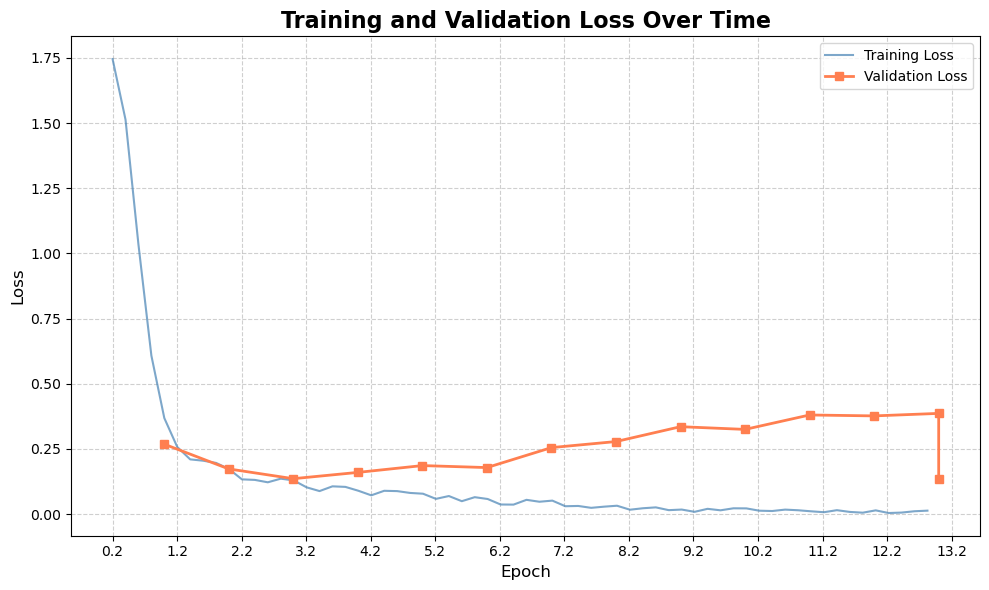

In [21]:
# =============================================================================
# Plot 1: Training & Validation Loss Curve (Fixed)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract logs from trainer history
logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

# Check if logs exist
if df_logs.empty:
    print("⚠️ No training logs found.")
else:
    plt.figure(figsize=(10, 6))

    # 1. Plot Training Loss (may be recorded at steps, not just epochs)
    # Filter rows that have 'loss' key
    df_train_loss = df_logs[df_logs['loss'].notna()]
    if not df_train_loss.empty:
        plt.plot(df_train_loss['epoch'], df_train_loss['loss'], 
                 label='Training Loss', color='steelblue', linewidth=1.5, alpha=0.7)

    # 2. Plot Validation Loss (recorded at epochs)
    # Filter rows that have 'eval_loss' key
    df_val_loss = df_logs[df_logs['eval_loss'].notna()]
    if not df_val_loss.empty:
        plt.plot(df_val_loss['epoch'], df_val_loss['eval_loss'], 
                 label='Validation Loss', color='coral', linewidth=2, marker='s', markersize=6)

    # Title and Labels
    plt.title('Training and Validation Loss Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Set x-ticks to show integer epochs if possible
    if not df_logs.empty:
        min_epoch = df_logs['epoch'].min()
        max_epoch = df_logs['epoch'].max()
        plt.xticks(np.arange(min_epoch, max_epoch + 1, 1.0))
        
    plt.tight_layout()
    # plt.savefig('distilbert_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    # print("✅ Loss curve saved as 'distilbert_loss_curve.png'")

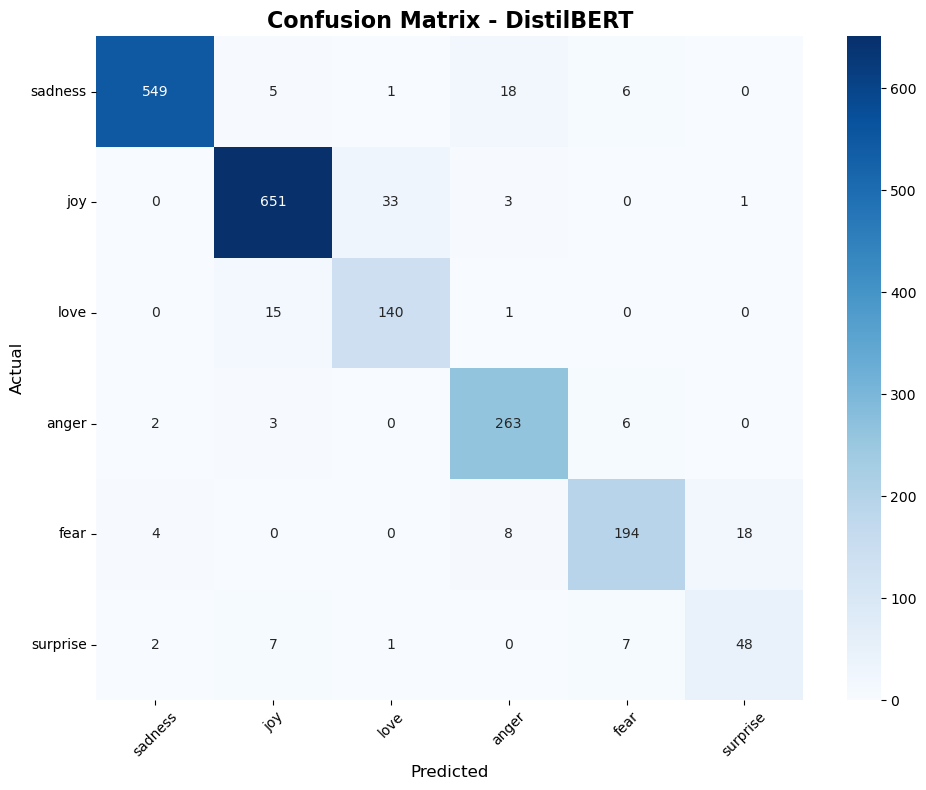

In [22]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - DistilBERT', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
# plt.savefig('distilbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# print("Confusion matrix saved as 'distilbert_confusion_matrix.png'")

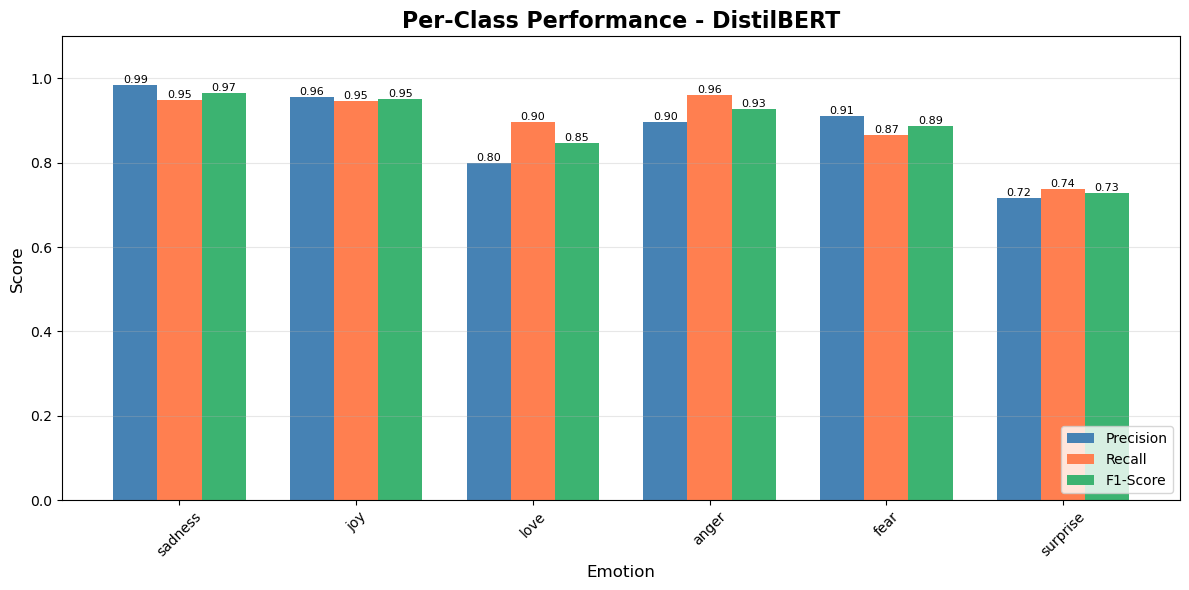

In [23]:
# Per-class performance visualization
precision, recall, f1, support = precision_recall_fscore_support(test_labels, test_preds, average=None)

x = np.arange(len(target_names))
width = 0.25

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width, precision, width, label='Precision', color='steelblue')
bars2 = plt.bar(x, recall, width, label='Recall', color='coral')
bars3 = plt.bar(x + width, f1, width, label='F1-Score', color='mediumseagreen')

plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Per-Class Performance - DistilBERT', fontsize=16, fontweight='bold')
plt.xticks(x, target_names, rotation=45)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig('distilbert_per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# print("Per-class performance chart saved as 'distilbert_per_class_performance.png'")

## 16. Error Analysis

In [24]:
# Analyze misclassifications
misclassified_indices = np.where(test_preds != test_labels)[0]
print(f"Total misclassified: {len(misclassified_indices)} / {len(test_labels)} ({len(misclassified_indices)/len(test_labels)*100:.2f}%)")

# Confusion pairs
confusion_pairs = Counter()
for idx in misclassified_indices:
    true_label = id2label[test_labels[idx]]
    pred_label = id2label[test_preds[idx]]
    confusion_pairs[(true_label, pred_label)] += 1

print("\nTop 10 Most Common Confusion Pairs:")
print("="*60)
for (true, pred), count in sorted(confusion_pairs.items(), key=lambda x: -x[1])[:10]:
    print(f"{true:12s} → {pred:12s}: {count:3d} times")

Total misclassified: 141 / 1986 (7.10%)

Top 10 Most Common Confusion Pairs:
joy          → love        :  33 times
fear         → surprise    :  18 times
sadness      → anger       :  18 times
love         → joy         :  15 times
fear         → anger       :   8 times
surprise     → fear        :   7 times
surprise     → joy         :   7 times
anger        → fear        :   6 times
sadness      → fear        :   6 times
sadness      → joy         :   5 times


In [25]:
# Show some misclassified examples
print("\nSample Misclassified Examples:")
print("="*80)

for i, idx in enumerate(misclassified_indices[:5]):
    true_label = id2label[test_labels[idx]]
    pred_label = id2label[test_preds[idx]]
    text = test_texts[idx]
    
    print(f"\nExample {i+1}:")
    print(f"Text: {text[:150]}..." if len(text) > 150 else f"Text: {text}")
    print(f"True: {true_label} | Predicted: {pred_label}")
    print("-" * 80)


Sample Misclassified Examples:

Example 1:
Text: i don t feel particularly agitated
True: fear | Predicted: anger
--------------------------------------------------------------------------------

Example 2:
Text: i were to go overseas or cross the border then i become a foreigner and will feel that way but never in my beloved land
True: love | Predicted: joy
--------------------------------------------------------------------------------

Example 3:
Text: i was feeling weird the other day and it went away about minutes after i took my metformin
True: fear | Predicted: surprise
--------------------------------------------------------------------------------

Example 4:
Text: when a friend dropped a frog down my neck
True: anger | Predicted: fear
--------------------------------------------------------------------------------

Example 5:
Text: i feel agitated with myself that i did not foresee her frustrations earlier leading to the ending of our relationship
True: fear | Predicted: ang

## 17. Conclusion

In [26]:
print("="*80)
print("DISTILBERT EMOTION CLASSIFICATION - FINAL SUMMARY")
print("="*80)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"✅ Test Macro-F1: {test_macro_f1:.4f}")
print(f"✅ Test Weighted-F1: {test_weighted_f1:.4f}")
print(f"\n📊 Model Size: 66M parameters (40% smaller than BERT)")
print(f"⚡ Inference Speed: ~60% faster than BERT/RoBERTa")
print(f"\n🎯 Best Performing Classes:")
for i in range(num_classes):
    p, r, f, s = precision[i], recall[i], f1[i], support[i]
    print(f"   - {target_names[i]:10s}: P={p:.3f}, R={r:.3f}, F1={f:.3f} (n={s})")

DISTILBERT EMOTION CLASSIFICATION - FINAL SUMMARY

✅ Test Accuracy: 0.9290 (92.90%)
✅ Test Macro-F1: 0.8844
✅ Test Weighted-F1: 0.9296

📊 Model Size: 66M parameters (40% smaller than BERT)
⚡ Inference Speed: ~60% faster than BERT/RoBERTa

🎯 Best Performing Classes:
   - sadness   : P=0.986, R=0.948, F1=0.967 (n=579)
   - joy       : P=0.956, R=0.946, F1=0.951 (n=688)
   - love      : P=0.800, R=0.897, F1=0.846 (n=156)
   - anger     : P=0.898, R=0.960, F1=0.928 (n=274)
   - fear      : P=0.911, R=0.866, F1=0.888 (n=224)
   - surprise  : P=0.716, R=0.738, F1=0.727 (n=65)
